# Safe absorbing states with partial observations

This notebook keeps the grid, LTL task, and discount factors from the fully observed example, but gives the controller noisy position observations and hides the LDBA state. A GRU DQN receives the most recent `k` observations and preceding actions. A persistent one-hot memory records which epsilon target the controller selected, so that branch identity is not lost when the selection falls outside the fixed history window.

The training cell displays the episode-return curve inline when training finishes. It does not open a separate graph window.


## Setup

A sensor error replaces the true position with a uniformly selected in-bounds, non-obstacle neighboring square. The environment state and the LDBA state remain internal to the simulator.


In [1]:
%matplotlib inline
import importlib
import random
import numpy as np
import torch

# Jupyter caches imported modules across reruns. Reload the project modules so
# this notebook always trains with the source currently on disk.
import dqn
import mdp
import controlsyn
importlib.reload(dqn)
importlib.reload(mdp)
importlib.reload(controlsyn)

from mdp import GridMDP
from oa import OmegaAutomaton
from controlsyn import ControlSynthesis

SEED = 17
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
np.set_printoptions(precision=4, suppress=True)


## Grid and task

This uses the paper's safe absorbing states layout and formula `(F G a | F G b) & G !c`.


In [2]:
shape = n_rows, n_cols = (5, 4)
structure = np.array([
    ['E', 'E', 'E', 'E'],
    ['E', 'E', 'E', 'T'],
    ['B', 'E', 'E', 'E'],
    ['T', 'E', 'T', 'E'],
    ['E', 'E', 'E', 'E'],
])
label = np.array([
    [(),       (),     ('c',), ()],
    [(),       (),     ('a',), ('b',)],
    [(),       (),     ('c',), ()],
    [('b',),   (),     ('a',), ()],
    [(),       ('c',), (),     ('c',)],
], dtype=object)

OBSERVATION_ERROR = 0.25
grid_mdp = GridMDP(
    shape=shape,
    structure=structure,
    label=label,
    observation_error=OBSERVATION_ERROR,
)

ltl = '(F G a | F G b) & G !c'
oa = OmegaAutomaton(ltl, 'ldba')
print('Grid shape:', grid_mdp.shape)
print('Grid actions:', grid_mdp.A)
print('Automaton states:', oa.shape[1], 'initial state:', oa.q0)
print('Epsilon edges:', oa.eps)


Grid shape: (5, 4)
Grid actions: ['U', 'D', 'R', 'L']
Automaton states: 4 initial state: 0
Epsilon edges: [[1, 2], [], [], []]


## Product model and observation check

The product MDP is used internally to generate rewards and transitions. The controller-facing observation omits `q`, the automaton state.


In [3]:
PAPER_DISCOUNT_NONACCEPTING = 0.99999
PAPER_DISCOUNT_ACCEPTING = 0.99
csrl = ControlSynthesis(
    grid_mdp,
    oa,
    discount_nonaccepting=PAPER_DISCOUNT_NONACCEPTING,
    discount_accepting=PAPER_DISCOUNT_ACCEPTING,
)

probe = (0, oa.q0, 1, 2)
probe_other_q = (0, min(1, oa.shape[1] - 1), 1, 2)
print('Full simulator state:', probe)
print('Controller observation:', csrl.observe_observation(probe, error_prob=0.0))
print('Same position, different hidden q:',
      csrl.observe_observation(probe_other_q, error_prob=0.0))


Full simulator state: (0, 0, 1, 2)
Controller observation: (0, 1, 2)
Same position, different hidden q: (0, 1, 2)


## Train the history-conditioned DQN

Each GRU input contains the visible `(pair, row, column)` one-hot observations, valid-token bits, preceding actions, and a persistent one-hot epsilon-target memory derived from the controller’s own selected action. Histories are left-padded to `HISTORY_LENGTH`; they reset at each episode, and the GRU state is recomputed from that fixed window on every decision. The target memory preserves which branch (`q1` or `q2`) was selected after the action itself leaves the window. For this automaton, epsilon edges are available only from q0. After taking one, the controller knows from its own action history that only grid moves remain; this mask does not inspect the hidden automaton state.

The settings below keep the original notebook's 200,000 episodes and 100-step rollout horizon. For a quick code check, lower `TRAIN_EPISODES` and `TRAIN_HORIZON` first.


Architecture preflight passed: 23 features per token; epsilon target memory is enabled.
Episode 0/200000
Episode 2000/200000; trailing 1000-episode return=0.065094
Episode 4000/200000; trailing 1000-episode return=0.073171
Episode 6000/200000; trailing 1000-episode return=0.076887
Episode 8000/200000; trailing 1000-episode return=0.066832
Episode 10000/200000; trailing 1000-episode return=0.076781
Episode 12000/200000; trailing 1000-episode return=0.079433
Episode 14000/200000; trailing 1000-episode return=0.070485
Episode 16000/200000; trailing 1000-episode return=0.077535
Episode 18000/200000; trailing 1000-episode return=0.073750
Episode 20000/200000; trailing 1000-episode return=0.062622
Episode 22000/200000; trailing 1000-episode return=0.080603
Episode 24000/200000; trailing 1000-episode return=0.076161
Episode 26000/200000; trailing 1000-episode return=0.075054
Episode 28000/200000; trailing 1000-episode return=0.075117
Episode 30000/200000; trailing 1000-episode return=0.078812

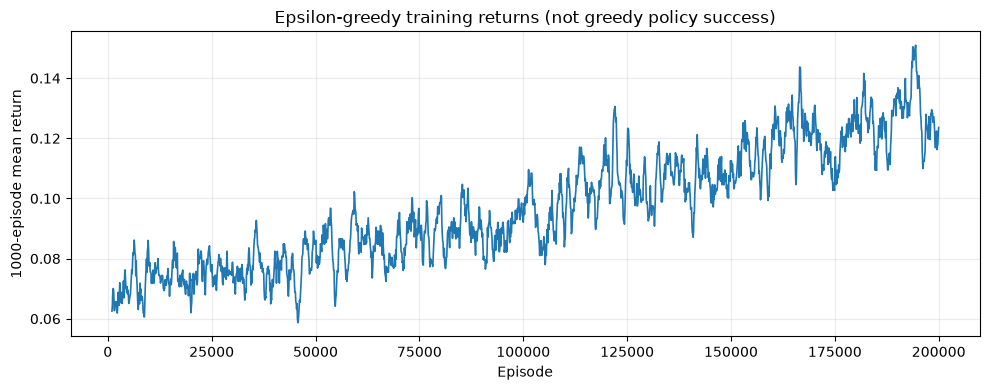

In [4]:
HISTORY_LENGTH = 8
GRU_HIDDEN_SIZE = 64
TRAIN_EPISODES = 200_000
TRAIN_HORIZON = 100

# Fail before the long run if the live kernel has a stale encoder or if the
# recurrent input cannot preserve which epsilon branch was selected.
import inspect
assert 'epsilon_commitment_mode' in inspect.signature(
    csrl.encode_observation_history
).parameters, 'Restart the kernel and rerun the setup cell to reload controlsyn.py.'
probe_square = next(iter(grid_mdp.states()))
probe_state = (csrl.shape[0] - 1, oa.q0, *probe_square)
probe_observation = csrl.observe_observation(probe_state, error_prob=0.0)
probe_history = csrl.encode_observation_history(
    [probe_observation],
    history_length=HISTORY_LENGTH,
    previous_actions=[None],
    epsilon_commitment_mode='target_one_hot',
)
EXPECTED_GRU_FEATURES = (
    csrl.shape[0] + grid_mdp.shape[0] + grid_mdp.shape[1]
    + 1 + csrl.shape[-1] + oa.shape[1]
)
assert probe_history.shape == (HISTORY_LENGTH, EXPECTED_GRU_FEATURES), (
    f'Expected {EXPECTED_GRU_FEATURES} features per token, '
    f'got {probe_history.shape[-1]}'
)
print('Architecture preflight passed:', EXPECTED_GRU_FEATURES,
      'features per token; epsilon target memory is enabled.')

Q, transition_counts, policy_net = csrl.deep_q_learning(
    T=TRAIN_HORIZON,
    K=TRAIN_EPISODES,
    epsilon_floor=0.1,
    learning_rate=1e-4,
    automaton_action_probability=0.2,
    architecture='gru',
    history_length=HISTORY_LENGTH,
    gru_hidden_size=GRU_HIDDEN_SIZE,
    partial_observation=True,
    batch_size=128,
    replay_capacity=100_000,
    target_update_every=250,
    checkpoint_dir='checkpoints_pomdp',
    return_diagnostics=True,
    return_model=True,
)

run_checkpoint = torch.load(
    csrl.last_checkpoint_path, map_location='cpu', weights_only=True
)
run_metadata = run_checkpoint['metadata']
assert run_metadata.get('recurrent_epsilon_commitment_mode') == 'target_one_hot', (
    'This checkpoint was trained with stale code; rerun after restarting the kernel.'
)
assert run_metadata['n_observations'] == EXPECTED_GRU_FEATURES, (
    f"Expected {EXPECTED_GRU_FEATURES} input features, "
    f"checkpoint has {run_metadata['n_observations']}"
)
assert run_metadata.get('epsilon_commit_mask_from_history') is True, (
    'The checkpoint did not use the post-epsilon action mask.'
)

# Show the return trend in this training cell when the run finishes.
from IPython.display import display
import matplotlib.pyplot as plt
if csrl.last_episode_returns.size:
    curve_window = min(1_000, len(csrl.last_episode_returns))
    cumulative_returns = np.concatenate(([0.0], np.cumsum(csrl.last_episode_returns)))
    rolling_returns = (
        cumulative_returns[curve_window:] - cumulative_returns[:-curve_window]
    ) / curve_window
    episode_axis = np.arange(curve_window, len(csrl.last_episode_returns) + 1)
    curve_stride = max(1, len(episode_axis) // 2_000)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(episode_axis[::curve_stride], rolling_returns[::curve_stride], linewidth=1.2)
    ax.set_xlabel('Episode')
    ax.set_ylabel(f'{curve_window}-episode mean return')
    ax.set_title('Epsilon-greedy training returns (not greedy policy success)')
    ax.grid(alpha=0.25)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


## Training summaries

Episode returns are available as `csrl.last_episode_returns`. They are also stored in the checkpoint with run metadata. The return summary is numeric and does not open a graph.


In [5]:
print('Return summary:', csrl.last_training_return_summary)
if csrl.last_episode_returns.size:
    print('Episode-return quantiles [0, .25, .5, .75, 1]:',
          np.quantile(csrl.last_episode_returns, [0, 0.25, 0.5, 0.75, 1]))
print('Checkpoint:', getattr(csrl, 'last_checkpoint_path', None))

counts_by_action = transition_counts.sum(axis=(0, 1, 2, 3))
def action_name(action):
    if action < len(grid_mdp.A):
        return grid_mdp.A[action]
    return f'eps->q{action - len(grid_mdp.A)}'
print('Training action counts:')
for action, count in enumerate(counts_by_action):
    if count:
        print(f'  {action_name(action):8s} {int(count)}')



print('Verified checkpoint architecture:', run_metadata['n_observations'],
      'features/token;', run_metadata['recurrent_epsilon_commitment_mode'],
      'epsilon memory; own-history action mask =',
      run_metadata['epsilon_commit_mask_from_history'])


Return summary: {'episodes': 200000, 'mean': 0.09679795643376167, 'std': 0.22536303942441702, 'first_window_mean': 0.06251641911691634, 'last_window_mean': 0.1236054060048491, 'window_episodes': 1000}
Episode-return quantiles [0, .25, .5, .75, 1]: [0.     0.     0.     0.     0.6303]
Checkpoint: /Users/connor/c/projects/thesis/code/checkpoints_pomdp/dqn_20261009T220331.799765Z_K200000_T100_915213e.pt
Training action counts:
  U        5202920
  D        4188584
  R        5925211
  L        4483285
  eps->q1  98176
  eps->q2  101824
Verified checkpoint architecture: 23 features/token; target_one_hot epsilon memory; own-history action mask = True


## Saved training-return curve

This cell can reload the newest POMDP checkpoint and redraw the 1,000-episode moving average without retraining. It is also shown automatically in the training cell when training finishes. These are epsilon-greedy returns from 100-step episodes, so use the per-square greedy rollout evaluation below to assess policy quality.


Loaded: checkpoints_pomdp/dqn_20261009T220331.799765Z_K200000_T100_915213e.pt
Run duration (seconds): 13564.7


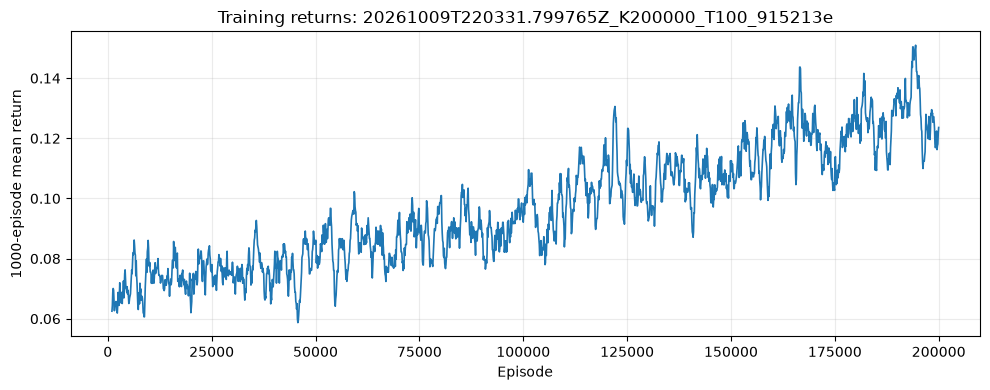

In [6]:
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import torch
from dqn import GRUDQN

checkpoint_candidates = sorted(
    Path('checkpoints_pomdp').glob('dqn_*.pt'),
    key=lambda path: path.stat().st_mtime,
)
if not checkpoint_candidates:
    raise FileNotFoundError('No POMDP checkpoint found in checkpoints_pomdp/')
latest_checkpoint_path = checkpoint_candidates[-1]
latest_checkpoint = torch.load(
    latest_checkpoint_path, map_location='cpu', weights_only=True
)
training_returns = latest_checkpoint['episode_returns'].numpy()
run_metadata = latest_checkpoint['metadata']
EPSILON_COMMITMENT_MODE = run_metadata.get(
    'recurrent_epsilon_commitment_mode',
    'bit' if run_metadata.get('recurrent_input_includes_epsilon_commitment', False) else 'none',
)
HISTORY_LENGTH = int(run_metadata['history_length'])
policy_net = GRUDQN(
    run_metadata['n_observations'],
    run_metadata['n_actions'],
    hidden_size=run_metadata['gru_hidden_size'],
    num_layers=run_metadata['gru_num_layers'],
)
policy_net.load_state_dict(latest_checkpoint['policy_state_dict'])
policy_net.eval()
window = min(1000, len(training_returns))
cumulative = np.concatenate(([0.0], np.cumsum(training_returns)))
rolling_returns = (cumulative[window:] - cumulative[:-window]) / window
x = np.arange(window, len(training_returns) + 1)
stride = max(1, len(x) // 2000)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x[::stride], rolling_returns[::stride], linewidth=1.2)
ax.set_xlabel('Episode')
ax.set_ylabel(f'{window}-episode mean return')
ax.set_title(f"Training returns: {run_metadata['run_id']}")
ax.grid(alpha=0.25)
fig.tight_layout()
print('Loaded:', latest_checkpoint_path)
print('Run duration (seconds):', round(run_metadata['elapsed_seconds'], 1))
display(fig)
plt.close(fig)


## Cold-start Q values at `a` and `b` squares

The returned `Q` array is a convenience table evaluated with a clean, one-observation history. A recurrent policy's actual Q values depend on recent observations/actions and its persistent epsilon-target memory; use `policy_net` with `encode_observation_history` for stateful decisions.


In [7]:
marker_cells = [
    (r, c)
    for r, c in grid_mdp.states()
    if grid_mdp.label[r, c] in (('a',), ('b',))
]
valid_action_ids = list(range(len(grid_mdp.A))) + [
    len(grid_mdp.A) + destination
    for outgoing in oa.eps
    for destination in outgoing
]
def action_name(action):
    if action < len(grid_mdp.A):
        return grid_mdp.A[action]
    return f'eps->q{action - len(grid_mdp.A)}'

for r, c in marker_cells:
    observation = csrl.observe_observation((0, oa.q0, r, c), error_prob=0.0)
    history = csrl.encode_observation_history(
        [observation], history_length=HISTORY_LENGTH, previous_actions=[None],
        epsilon_committed=False,
        epsilon_commitment_mode=EPSILON_COMMITMENT_MODE,
    ).unsqueeze(0)
    with torch.no_grad():
        values = policy_net(history).squeeze(0).cpu().numpy()
    print(f"\nlabel={grid_mdp.label[r, c]}, square=({r}, {c})")
    for action in valid_action_ids:
        print(f'  {action_name(action):8s} Q={float(values[action]):.8f}')



label=('a',), square=(1, 2)
  U        Q=0.33745900
  D        Q=0.22210976
  R        Q=0.74286240
  L        Q=0.43357199
  eps->q1  Q=0.03788587
  eps->q2  Q=0.05717258

label=('b',), square=(1, 3)
  U        Q=0.80633628
  D        Q=0.82671756
  R        Q=0.99544042
  L        Q=0.72974169
  eps->q1  Q=0.01125379
  eps->q2  Q=0.72392708

label=('b',), square=(3, 0)
  U        Q=0.95069909
  D        Q=0.82624012
  R        Q=0.82538539
  L        Q=0.96772730
  eps->q1  Q=0.01431303
  eps->q2  Q=0.75785470

label=('a',), square=(3, 2)
  U        Q=0.90277267
  D        Q=0.69313759
  R        Q=0.86028999
  L        Q=0.84831417
  eps->q1  Q=0.81160980
  eps->q2  Q=-0.01831034


## Inspect Q values along histories that outlast the window

These diagnostics build two otherwise identical long histories: one follows `eps->q1`, the other `eps->q2`; the epsilon action itself is then outside the 8-step observation window. The persistent target memory should still distinguish the branches. The simulator is used only to construct the example; the policy input contains observations, the controller's own actions, and its own remembered epsilon target, never the hidden automaton state.


In [8]:
def q_values_for_history(observations, previous_actions, *, epsilon_committed, epsilon_target=None):
    history = csrl.encode_observation_history(
        observations,
        history_length=HISTORY_LENGTH,
        previous_actions=previous_actions,
        partial_observation=True,
        epsilon_committed=epsilon_committed,
        epsilon_target=epsilon_target,
        epsilon_commitment_mode=EPSILON_COMMITMENT_MODE,
    ).unsqueeze(0)
    with torch.no_grad():
        values = policy_net(history).squeeze(0).cpu().numpy()
    allowed = (
        list(range(len(grid_mdp.A)))
        if run_metadata.get('epsilon_commit_mask_from_history', False)
        and epsilon_committed
        else valid_action_ids
    )
    values[[action for action in range(len(values)) if action not in allowed]] = -np.inf
    return values

def print_context(description, observations, previous_actions, *, epsilon_committed, epsilon_target=None):
    values = q_values_for_history(
        observations, previous_actions, epsilon_committed=epsilon_committed,
        epsilon_target=epsilon_target,
    )
    ranked = sorted(
        ((float(values[a]), action_name(a)) for a in range(len(values))
         if np.isfinite(values[a])),
        reverse=True,
    )
    print(description)
    print('  ', ', '.join(f'{name}={value:.6f}' for value, name in ranked))

blank = (0, 0, 0)
a_trap = (0, 3, 2)
b_trap = (0, 3, 0)
eps_to_q1 = len(grid_mdp.A) + 1
eps_to_q2 = len(grid_mdp.A) + 2
print_context('q0 at a blank square', [blank], [None], epsilon_committed=False)
long_blank_history = [blank] * (HISTORY_LENGTH + 2)
q1_actions = [eps_to_q1] + [0] * (len(long_blank_history) - 1)
q2_actions = [eps_to_q2] + [0] * (len(long_blank_history) - 1)
print_context('q1 after its epsilon action has left the history window',
              long_blank_history, q1_actions, epsilon_committed=True, epsilon_target=1)
print_context('q2 after its epsilon action has left the history window',
              long_blank_history, q2_actions, epsilon_committed=True, epsilon_target=2)
print_context('q1 at the a trap',
              [a_trap, a_trap], [None, eps_to_q1], epsilon_committed=True, epsilon_target=1)
print_context('q2 at the b trap',
              [b_trap, b_trap], [None, eps_to_q2], epsilon_committed=True, epsilon_target=2)


q0 at a blank square
   L=1.007133, D=0.980082, U=0.975650, R=0.876229, eps->q1=0.019358, eps->q2=-0.016119
q1 after its epsilon action has left the history window
   U=0.284641, L=0.282683, D=0.209023, R=0.191813
q2 after its epsilon action has left the history window
   U=0.637809, L=0.560832, D=0.522702, R=0.441005
q1 at the a trap
   R=1.003452, L=0.966795, U=0.906246, D=0.877255
q2 at the b trap
   D=0.805828, L=0.780046, R=0.739230, U=0.729983


## POMDP rollout evaluation

The evaluator maintains only the last `k` controller observations and actions when choosing actions. It uses the hidden simulator state only to advance the environment, calculate rewards, and stop once a proven rejecting sink is reached.

Returns are truncated at `EVAL_HORIZON`. Since the nonaccepting discount is `0.99999`, short horizons can substantially underestimate long-run returns; compare horizons and interpret these as finite-horizon measurements.


In [9]:
GLOBAL_EPSILON_ACTIONS = sorted({
    len(grid_mdp.A) + destination
    for outgoing in oa.eps
    for destination in outgoing
})
GLOBAL_ACTION_IDS = list(range(len(grid_mdp.A))) + GLOBAL_EPSILON_ACTIONS
GLOBAL_ACTION_SET = set(GLOBAL_ACTION_IDS)

REJECTING_SINK_QS = {
    q for q in range(oa.shape[1])
    if not oa.eps[q]
    and oa.delta[q]
    and all(destination == q for destination in oa.delta[q].values())
    and not any(
        status is True
        for statuses in oa.acc[q].values()
        for status in statuses
    )
}

def pomdp_greedy_return(start_square, n_runs=100, max_steps=1_000, seed=123):
    r, c = map(int, start_square)
    if (r, c) not in grid_mdp.states():
        raise ValueError(f'{start_square} is not a valid grid square')

    # The sensor currently draws noise from NumPy's global RNG. Seed it here
    # to make repeated calls reproducible. Transition sampling uses a local RNG.
    np.random.seed(seed)
    rng = np.random.default_rng(seed + 1)
    start_state = (0, oa.q0, r, c)
    returns = []
    action_counts = np.zeros(csrl.shape[-1], dtype=np.int64)

    for _ in range(n_runs):
        state = start_state
        observations = [csrl.observe_observation(state)]
        previous_actions = [None]
        epsilon_committed = False
        epsilon_target = None
        total_return = 0.0
        discount_so_far = 1.0

        for _step in range(max_steps):
            history = csrl.encode_observation_history(
                observations,
                history_length=HISTORY_LENGTH,
                previous_actions=previous_actions,
                partial_observation=True,
                epsilon_committed=epsilon_committed,
                epsilon_target=epsilon_target,
                epsilon_commitment_mode=EPSILON_COMMITMENT_MODE,
            ).unsqueeze(0)
            with torch.no_grad():
                action_values = policy_net(history).squeeze(0).cpu().numpy()
            allowed_actions = (
                list(range(len(grid_mdp.A)))
                if (run_metadata.get('epsilon_commit_mask_from_history', False)
                    and epsilon_committed)
                else GLOBAL_ACTION_IDS
            )
            action_values[[a for a in range(csrl.shape[-1])
                           if a not in set(allowed_actions)]] = -np.inf
            action = int(np.argmax(action_values))
            action_counts[action] += 1

            reward = float(csrl.reward[state])
            total_return += discount_so_far * reward
            discount_so_far *= (
                csrl.discount_accepting if reward > 0
                else csrl.discount_nonaccepting
            )

            if action in csrl.A[state]:
                successors, probabilities = csrl.transition_probs[state][action]
            else:
                # An unavailable epsilon attempt is an observation-independent no-op.
                successors, probabilities = [state], [1.0]
            state = successors[rng.choice(len(successors), p=probabilities)]
            if action in GLOBAL_EPSILON_ACTIONS and epsilon_target is None:
                epsilon_target = action - len(grid_mdp.A)
            epsilon_committed = epsilon_committed or epsilon_target is not None

            observations.append(csrl.observe_observation(state))
            previous_actions.append(action)
            observations = observations[-HISTORY_LENGTH:]
            previous_actions = previous_actions[-HISTORY_LENGTH:]

            if state[1] in REJECTING_SINK_QS:
                break

        returns.append(total_return)

    returns = np.asarray(returns, dtype=float)
    mean = float(returns.mean())
    standard_error = (
        float(returns.std(ddof=1) / np.sqrt(n_runs)) if n_runs > 1 else 0.0
    )
    return {
        'square': (r, c),
        'mean_return': mean,
        'ci95': (mean - 1.96 * standard_error, mean + 1.96 * standard_error),
        'horizon': int(max_steps),
        'samples': returns,
        'action_counts': action_counts,
    }


## Measured returns by starting square

Change `EVAL_RUNS` or `EVAL_HORIZON` to trade runtime for a more stable estimate or a longer measurement window. The function returns the individual samples and action counts as well as the mean and confidence interval.


In [10]:
EVAL_RUNS = 100
EVAL_HORIZON = 1_000

evaluation = []
for index, (r, c) in enumerate(grid_mdp.states()):
    result = pomdp_greedy_return(
        (r, c),
        n_runs=EVAL_RUNS,
        max_steps=EVAL_HORIZON,
        seed=SEED + index,
    )
    evaluation.append(result)
    lo, hi = result['ci95']
    print(
        f"{(r, c)}: measured={result['mean_return']:.5f} "
        f"(95% CI {lo:.5f} to {hi:.5f}, horizon={result['horizon']})"
    )


(0, 0): measured=0.12149 (95% CI 0.06005 to 0.18293, horizon=1000)
(0, 1): measured=0.08263 (95% CI 0.03049 to 0.13478, horizon=1000)
(0, 2): measured=0.00000 (95% CI 0.00000 to 0.00000, horizon=1000)
(0, 3): measured=0.90985 (95% CI 0.85348 to 0.96621, horizon=1000)
(1, 0): measured=0.05649 (95% CI 0.01205 to 0.10094, horizon=1000)
(1, 1): measured=0.10963 (95% CI 0.04820 to 0.17106, horizon=1000)
(1, 2): measured=0.65052 (95% CI 0.55672 to 0.74432, horizon=1000)
(1, 3): measured=0.99985 (95% CI 0.99983 to 0.99986, horizon=1000)
(2, 0): measured=0.00000 (95% CI 0.00000 to 0.00000, horizon=1000)
(2, 1): measured=0.28244 (95% CI 0.19439 to 0.37050, horizon=1000)
(2, 2): measured=0.00000 (95% CI 0.00000 to 0.00000, horizon=1000)
(2, 3): measured=0.84986 (95% CI 0.77953 to 0.92019, horizon=1000)
(3, 0): measured=0.81993 (95% CI 0.74426 to 0.89561, horizon=1000)
(3, 1): measured=0.36990 (95% CI 0.27482 to 0.46498, horizon=1000)
(3, 2): measured=0.99992 (95% CI 0.99992 to 0.99992, horizon=1

## Next-step diagnostics

- `csrl.last_episode_returns` contains one discounted epsilon-greedy rollout return per training episode; the training summary cell plots its moving average inline.
- `transition_counts` gives training visits by product state and action.
- `evaluation` contains per-square greedy rollout samples and action counts, with the true `q` state hidden from the policy.
- `policy_net` expects a tensor shaped `(batch, HISTORY_LENGTH, features)`. Build the current history with `csrl.encode_observation_history(...)`, pass the remembered epsilon target, and pass the result to the network for action values.
